📍Peak at 2, height=1.00 => Region: (1, 8)

✅ Merged Regions:
➡️ (1, 8)
📍Peak at 15, height=0.80 => Region: (13, 17)

✅ Merged Regions:
➡️ (1, 8)
➡️ (13, 17)
📍Peak at 22, height=1.00 => Region: (20, 24)

✅ Merged Regions:
➡️ (1, 8)
➡️ (13, 17)
➡️ (20, 24)


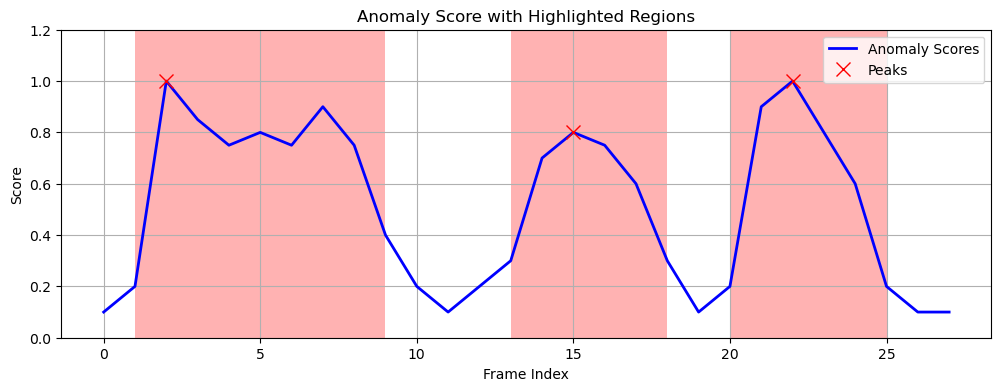

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, peak_widths
import matplotlib.patches as patches

# Giả lập anomaly scores
anomaly_scores = np.array([
    0.1, 0.2,1,0.85,0.75, 0.8, 0.75, 0.9, 0.75, 0.4, 0.2,  # Peak 1
    0.1, 0.2, 0.3, 0.7, 0.8, 0.75, 0.6, 0.3,   # Peak 2 (gần Peak 1)
    0.1, 0.2, 0.9, 1.0, 0.8, 0.6, 0.2,         # Peak 3 (xa)
    0.1, 0.1
])

# Ngưỡng
HIGH_THRESHOLD = 0.7 #height
LOW_THRESHOLD = 0.3 # promience  = height - max(min(a), min(b)) = 0.9 - 0.1 = 0.8 >= 0.3 
 0.9  1 -09
# Tìm đỉnh
peaks, properties = find_peaks(anomaly_scores, height=HIGH_THRESHOLD, prominence=LOW_THRESHOLD)

widths, _, left_ips, right_ips = peak_widths(anomaly_scores, peaks, rel_height=0.5) # h = peak_height - prominence * rel_height 0.9 - 0.8 * 0.5 = 0.5

# Tạo vùng bất thường từ các đỉnh
anomaly_regions = []
total_frames = len(anomaly_scores)

for i, peak in enumerate(peaks):
    start = max(0, int(left_ips[i]))
    end = min(total_frames-1, int(right_ips[i]))

    anomaly_regions.append((start, end))
    print(f"📍Peak at {peak}, height={anomaly_scores[peak]:.2f} => Region: ({start}, {end})")


    print("\n✅ Merged Regions:")
    for r in anomaly_regions:
        print(f"➡️ {r}")

# Vẽ biểu đồ trực quan
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(anomaly_scores, label="Anomaly Scores", color='blue', linewidth=2)
ax.plot(peaks, anomaly_scores[peaks], "x", color='red', markersize=10, label="Peaks")

for start, end in anomaly_regions:
    rect = patches.Rectangle((start, 0), end-start+1, 1.2, linewidth=0, color='red', alpha=0.3)
    ax.add_patch(rect)

ax.set_ylim(0, 1.2)
ax.set_title("Anomaly Score with Highlighted Regions")
ax.set_xlabel("Frame Index")
ax.set_ylabel("Score")
ax.legend()
plt.grid(True)
plt.show()


## giải thích lại height, promience

height > 0.7
promience
điểm thấp nhất bên trái là 0.1
điểm thấp nhất bên phải là 0.2